In [1]:
from anomaly_detector.backend_ml_llm.anomaly_d import anomaly_detector
from anomaly_detector.backend_ml_llm.mistral_raport_generator import report_generator
import pandas as pd

df = pd.DataFrame()
df = anomaly_detector.read_csv_add_features_and_model("data/bigger_test.csv")
wiadomosc = report_generator.generate_report(df)
num_cols = df.select_dtypes(include='number').columns

print(df)

      transaction_id       customer_name   amount  age  hour  \
0                  1  Grzegorz Kozlowski   137.38   57    22   
1                  2        Adam Wozniak   115.16   18    18   
2                  3       Grzegorz Krol   142.67   21    21   
3                  4    Krzysztof Wojcik   173.31   47     7   
4                  5   Agnieszka Wozniak   111.80   29    10   
...              ...                 ...      ...  ...   ...   
4995            4996  Lukasz Lewandowski  1092.15   24     4   
4996            4997   Michal Piotrowski   144.90   22    14   
4997            4998    Tomasz Szymanski   228.95   24    16   
4998            4999      Anna Michalski   148.28   51    11   
4999            5000    Tomasz Wieczorek    90.32   49    21   

      transaction_id_diff_mean  transaction_id_zscore  amount_diff_mean  \
0                      -2499.5              -1.731531        -38.691408   
1                      -2498.5              -1.730839        -60.911408   
2     

In [2]:
    print(wiadomosc)

 Wiersz 0: główną przyczynę anomalii stanowi kolumna 'transaction_id' (z-score=-1.73, roznica od średniej kroczacej=0.00, flaga outlier IQR=nie). Wykryta przez 3/3 modeli: Isolation Forest, LOF, One-Class SVM.
Wiersz 1: główną przyczynę anomalii stanowi kolumna 'transaction_id' (z-score=-1.73, roznica od średniej kroczacej=0.50, flaga outlier IQR=nie). Wykryta przez 3/3 modeli: Isolation Forest, LOF, One-Class SVM.
Wiersz 2: główną przyczynę anomalii stanowi kolumna 'transaction_id' (z-score=-1.73, roznica od średniej kroczacej=1.00, flaga outlier IQR=nie). Wykryta przez 3/3 modeli: Isolation Forest, LOF, One-Class SVM.
Wiersz 3: główną przyczynę anomalii stanowi kolumna 'transaction_id' (z-score=-1.73, roznica od średniej kroczacej=1.50, flaga outlier IQR=nie). Wykryta przez 3/3 modeli: Isolation Forest, LOF, One-Class SVM.
Wiersz 4: główną przyczynę anomalii stanowi kolumna 'transaction_id' (z-score=-1.73, roznica od średniej kroczacej=2.00, flaga outlier IQR=nie). Wykryta przez 2/3 

In [3]:
from anomaly_detector.backend_ml_llm.mistral_raport_generator import report_generator
import inspect
print(inspect.getsource(report_generator))

class report_generator:

    @staticmethod
    def ask_mistral(prompt: str, model: str = "mistral") -> str:
        response = requests.post(
            "http://localhost:11434/api/generate",
            json={"model": model, "prompt": prompt, "stream": False}
        )
        response.raise_for_status()
        return response.json()["response"]

    @staticmethod
    def build_row_facts(df: pd.DataFrame, num_cols) -> str:
        anomalies_df = df[df['Anomaly_Final'] == 1]
        lines = []

        for idx, row in anomalies_df.iterrows():
            zscore_cols = {c: row[f'{c}_zscore'] for c in num_cols if f'{c}_zscore' in row}
            main_col = max(zscore_cols, key=lambda c: abs(zscore_cols[c]))
            main_zscore = zscore_cols[main_col]
            main_diff_roll = row.get(f'{main_col}_diff_from_rolling_mean', None)
            main_is_outlier = row.get(f'{main_col}_is_outlier', 0)

            votes = int(row['Anomaly_IF']) + int(row['Anomaly_LOF']) + int(row['Anoma

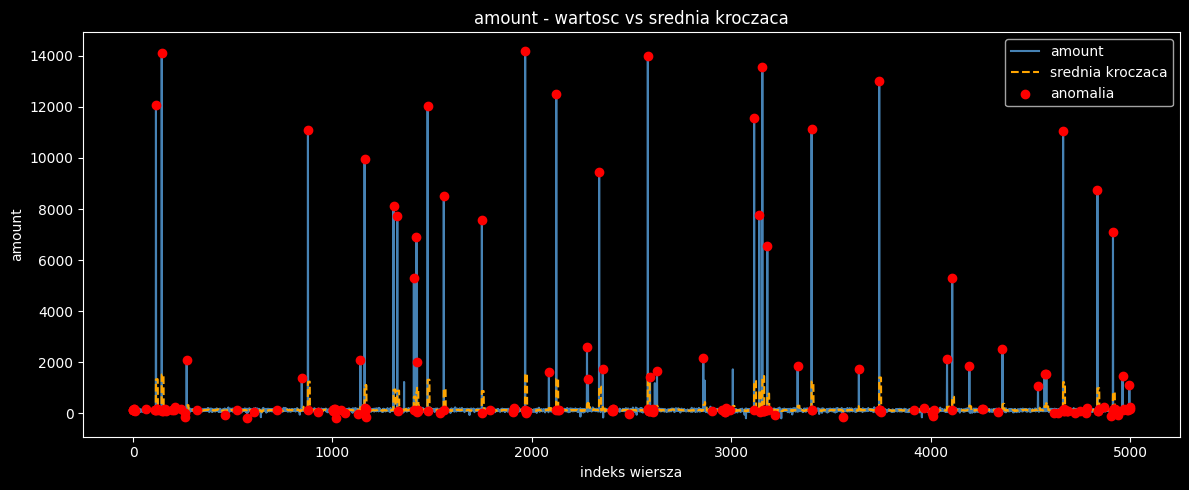

In [4]:
from visualization import anomaly_visualizer
anomaly_visualizer.plot_rolling(df, "amount")

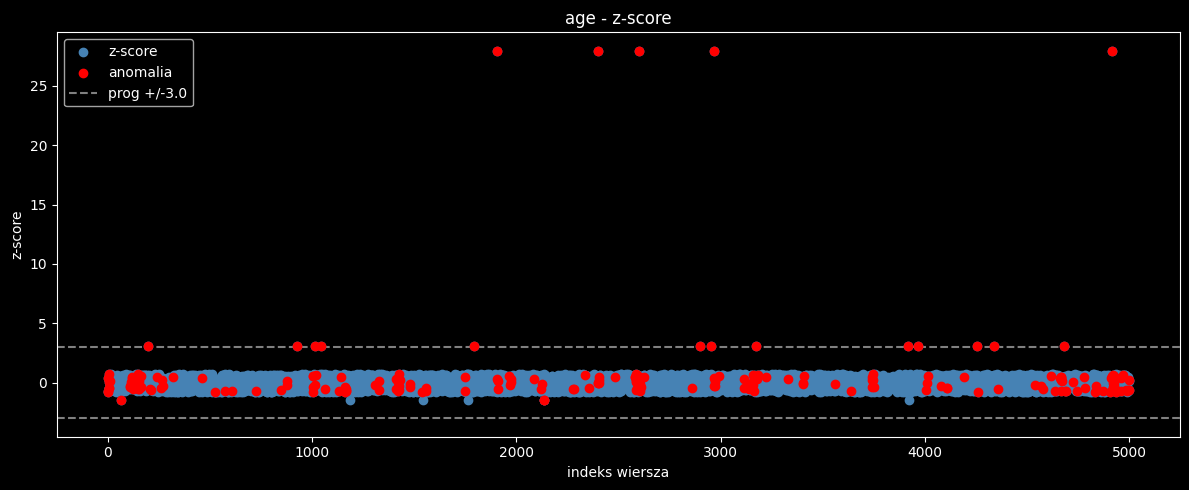

In [5]:
anomaly_visualizer.plot_zscore(df, "age")

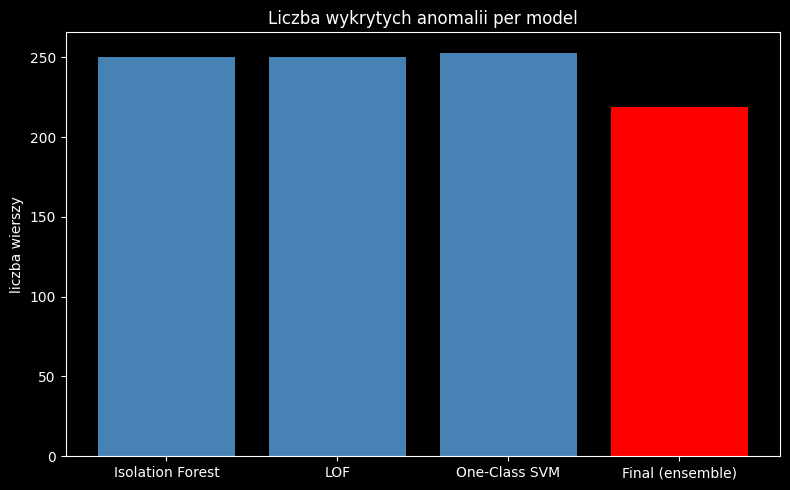

In [6]:
anomaly_visualizer.plot_model_votes(df)

In [7]:
anomaly_visualizer.plot_outlier_heatmap(df, num_cols)